# Train a coherent decision head on the Clef-Flash Qwen backbone

The previous experiment showed that Clef-Flash can assign inconsistent probabilities when one sentiment variable is requested as `choice`, `score`, and separate `noul` questions. Here we replace its decision head while keeping its Qwen3.5-9B backbone frozen.

The new head learns one utility per runtime proposition. A single softmax is the canonical distribution, so categorical, ordinal, and binary views are coherent by construction. Training optimizes predictive quality and calibration; coherence does not have to be learned.

In [1]:
from dataclasses import asdict
from pathlib import Path
import copy
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from decision_models.base import CompatibilityScorer
from decision_models.benchmark import (
    SENTIMENT_DESCRIPTIONS, SENTIMENT_LABELS, coherence_metrics, load_tweet_eval_records,
)
from decision_models.clef_flash import ClefFlashClient
from decision_models.coherent import SharedUtilityHead
from decision_models.training import (
    classification_metrics, decision_logits, encode_in_batches, fit_temperature, train_head,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Data and runtime configuration

TweetEval sentiment supplies an exclusive, exhaustive, and ordered three-class variable. The labels have both nominal (`choice`) and ordinal (`score`) interpretations. The test split is never used to update the head. Environment variables make the expensive run adjustable without editing the notebook.

In [2]:
RUN_TRAINING = os.environ.get('RUN_COHERENT_TRAINING', '0') == '1'
N_TRAIN = int(os.environ.get('COHERENT_N_TRAIN', '1000'))
N_VALIDATION = int(os.environ.get('COHERENT_N_VALIDATION', '300'))
N_TEST = int(os.environ.get('COHERENT_N_TEST', '300'))
ENCODE_BATCH_SIZE = int(os.environ.get('COHERENT_ENCODE_BATCH', '4'))
EPOCHS = int(os.environ.get('COHERENT_EPOCHS', '25'))
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

train_records = load_tweet_eval_records('train', N_TRAIN)
validation_records = load_tweet_eval_records('validation', N_VALIDATION)
test_records = load_tweet_eval_records('test', N_TEST)
print({'run_training': RUN_TRAINING, 'device': DEVICE, 'train': len(train_records), 'validation': len(validation_records), 'test': len(test_records)})
pd.Series([r['label_name'] for r in train_records]).value_counts(normalize=True).rename('train_fraction')

{'run_training': True, 'device': 'cuda', 'train': 1000, 'validation': 300, 'test': 300}


neutral     0.460
positive    0.389
negative    0.151
Name: train_fraction, dtype: float64

## 2. Freeze Qwen and cache representations

We load the official Clef-Flash release, discard its joint decision head, and expose only its Qwen3.5-9B text backbone. Backbone parameters are frozen. Each tweet is encoded once and moved to CPU, so optimization below trains only a small compatibility scorer.

In [3]:
if RUN_TRAINING:
    if DEVICE != 'cuda':
        raise RuntimeError('The full Clef-Flash backbone run requires CUDA.')
    clef = ClefFlashClient.from_pretrained(device=DEVICE)
    encoder = clef.as_frozen_text_encoder(max_length=128)

    train_texts = [r['state']['text'] for r in train_records]
    validation_texts = [r['state']['text'] for r in validation_records]
    test_texts = [r['state']['text'] for r in test_records]
    train_states = encode_in_batches(encoder, train_texts, batch_size=ENCODE_BATCH_SIZE)
    validation_states = encode_in_batches(encoder, validation_texts, batch_size=ENCODE_BATCH_SIZE)
    test_states = encode_in_batches(encoder, test_texts, batch_size=ENCODE_BATCH_SIZE)
    question = encoder.encode_texts(['What is the overall sentiment of this text?']).float()
    options = encoder.encode_texts([SENTIMENT_DESCRIPTIONS[x] for x in SENTIMENT_LABELS]).float().unsqueeze(0)
    train_targets = torch.tensor([r['label'] for r in train_records], dtype=torch.long)
    validation_targets = torch.tensor([r['label'] for r in validation_records], dtype=torch.long)
    test_targets = torch.tensor([r['label'] for r in test_records], dtype=torch.long)
    print('cached:', train_states.shape, validation_states.shape, test_states.shape, 'hidden:', encoder.hidden_size)

    # Original Clef-Flash head on exactly the same held-out examples.
    clef_answers = [clef.decide(r['state'], r['questions']) for r in test_records]
    clef_choice_probs = torch.tensor([
        [a['sentiment_choice']['probabilities'][label] for label in SENTIMENT_LABELS]
        for a in clef_answers
    ])
    clef_choice_logits = clef_choice_probs.clamp_min(1e-8).log()
    clef_metrics = classification_metrics(clef_choice_logits, test_targets)
else:
    print('Set RUN_COHERENT_TRAINING=1 to load Qwen and train the head.')

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/760 [00:00<?, ?it/s]

[transformers] `causal_conv1d_fn` is falling back to its reference PyTorch implementation because `causal_conv1d` is not installed. This is correct but much slower; install `causal_conv1d` for the optimized kernel.


[transformers] `chunk_gated_delta_rule` is falling back to its reference PyTorch implementation because `flash-linear-attention` is not installed. This is correct but much slower; install `flash-linear-attention` for the optimized kernel.


cached: torch.Size([1000, 4096]) torch.Size([300, 4096]) torch.Size([300, 4096]) hidden: 4096


## 3. Train the compatibility head

For state vector $s$, question vector $q$, and runtime option vector $o_i$, the head learns utilities $u_i = h(s,q)^Tg(o_i)/\sqrt{d}$. We optimize label-smoothed cross-entropy plus 0.1 times the multiclass Brier score. No consistency penalty is necessary because all output forms will reuse the same utilities.

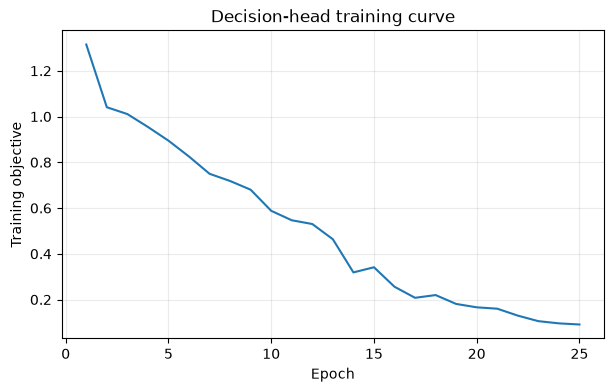

In [4]:
if RUN_TRAINING:
    scorer = CompatibilityScorer(encoder.hidden_size, projection_size=256).to(DEVICE)
    question = question.to(DEVICE)
    options = options.to(DEVICE)

    with torch.inference_mode():
        initial_logits = decision_logits(scorer, test_states.to(DEVICE), question, options).cpu()
    initial_metrics = classification_metrics(initial_logits, test_targets)

    history = train_head(
        scorer, train_states, train_targets, question, options,
        epochs=EPOCHS, batch_size=64, learning_rate=3e-4,
        label_smoothing=0.02, brier_weight=0.1, seed=SEED,
    )
    with torch.inference_mode():
        test_logits = decision_logits(scorer, test_states.to(DEVICE), question, options).cpu()
        validation_logits = decision_logits(scorer, validation_states.to(DEVICE), question, options).cpu()
    trained_metrics = classification_metrics(test_logits, test_targets)
    temperature = fit_temperature(validation_logits, validation_targets)
    calibrated_test_logits = test_logits / temperature
    calibrated_metrics = classification_metrics(calibrated_test_logits, test_targets)

    plt.figure(figsize=(7, 4))
    plt.plot(range(1, len(history) + 1), history)
    plt.xlabel('Epoch'); plt.ylabel('Training objective'); plt.title('Decision-head training curve'); plt.grid(alpha=.25)
    plt.show()

## 4. Predictive and calibration outcome

Accuracy asks whether the selected class is correct. NLL and Brier evaluate the full predictive distribution; ECE summarizes confidence-frequency alignment in ten bins. They are different properties from logical coherence.

In [5]:
if RUN_TRAINING:
    comparison = pd.DataFrame(
        [asdict(clef_metrics), asdict(calibrated_metrics)],
        index=[
            'pretrained Clef-Flash (original head)',
            'pretrained Clef-Flash (coherent head replacement)',
        ],
    )
    display(comparison)

    training_diagnostics = pd.DataFrame(
        [asdict(initial_metrics), asdict(trained_metrics), asdict(calibrated_metrics)],
        index=['random replacement head', 'trained CE + Brier', 'trained + validation temperature'],
    )
    display(training_diagnostics)
    print('validation-fitted temperature:', float(temperature))
    print('Accuracy is unchanged by positive temperature scaling; NLL/Brier/ECE measure its calibration effect.')

,accuracy,negative_log_likelihood,brier,expected_calibration_error
pretrained Clef-Flash (original head),0.636667,0.872849,0.538179,0.187349
pretrained Clef-Flash (coherent head replacement),0.573333,0.955651,0.562857,0.053571


,accuracy,negative_log_likelihood,brier,expected_calibration_error
random replacement head,0.213333,1.217958,0.735527,0.198366
trained CE + Brier,0.573333,1.578089,0.683395,0.283037
trained + validation temperature,0.573333,0.955651,0.562857,0.053571


validation-fitted temperature: 3.274637222290039
Accuracy is unchanged by positive temperature scaling; NLL/Brier/ECE measure its calibration effect.


,confidence,accuracy,count
0,0.375782,0.100000,10
1,0.452849,0.490909,55
2,0.549567,0.559140,93
3,0.650482,0.661290,62
4,0.749508,0.623188,69
5,0.813081,0.727273,11


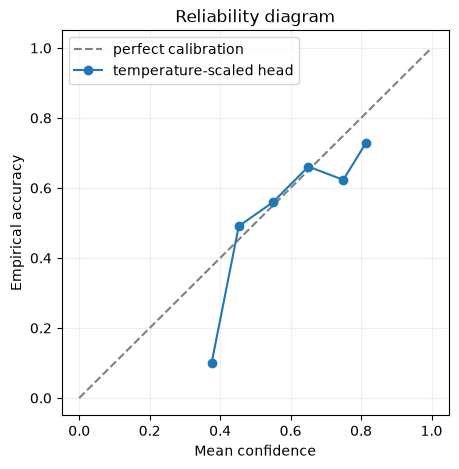

In [6]:
def reliability_points(probabilities, targets, bins=10):
    confidence, prediction = probabilities.max(-1)
    correct = prediction.eq(targets).float()
    rows = []
    for lo, hi in zip(torch.linspace(0, 1, bins + 1)[:-1], torch.linspace(0, 1, bins + 1)[1:]):
        mask = (confidence > lo) & (confidence <= hi)
        if mask.any():
            rows.append((float(confidence[mask].mean()), float(correct[mask].mean()), int(mask.sum())))
    return pd.DataFrame(rows, columns=['confidence', 'accuracy', 'count'])

if RUN_TRAINING:
    reliability = reliability_points(calibrated_test_logits.softmax(-1), test_targets)
    display(reliability)
    plt.figure(figsize=(5, 5))
    plt.plot([0, 1], [0, 1], '--', color='grey', label='perfect calibration')
    plt.plot(reliability.confidence, reliability.accuracy, 'o-', label='temperature-scaled head')
    plt.xlabel('Mean confidence'); plt.ylabel('Empirical accuracy'); plt.title('Reliability diagram'); plt.legend(); plt.grid(alpha=.2)
    plt.show()

## 5. Verify structural probability coherence

The trained logits are interpreted once as a canonical softmax. `choice` returns it directly; `score` uses it to compute an expectation; and `noul(label)` returns the matching marginal and its complement. The diagnostics below should be zero up to floating-point precision, regardless of accuracy or calibration.

In [7]:
if RUN_TRAINING:
    choice_probs = SharedUtilityHead.choice(calibrated_test_logits)
    noul_yes = torch.stack([SharedUtilityHead.noul(calibrated_test_logits, i)[:, 1] for i in range(3)], dim=-1)
    score_probs, expected_score = SharedUtilityHead.score(calibrated_test_logits, torch.tensor([-1., 0., 1.]))
    replacement_coherence = {
        'max_choice_noul_gap': float((choice_probs - noul_yes).abs().max()),
        'max_choice_score_gap': float((choice_probs - score_probs).abs().max()),
        'max_noul_simplex_error': float((noul_yes.sum(-1) - 1).abs().max()),
    }
    clef_coherence_rows = [asdict(coherence_metrics(a)) for a in clef_answers]
    clef_coherence = pd.DataFrame(clef_coherence_rows).mean()
    coherence_comparison = pd.DataFrame({
        'pretrained Clef-Flash (original head)': {
            'choice_noul_gap': clef_coherence['choice_noul_l1'],
            'choice_score_gap': clef_coherence['choice_score_l1'],
            'noul_simplex_error': clef_coherence['noul_simplex_error'],
        },
        'pretrained Clef-Flash (coherent head replacement)': {
            'choice_noul_gap': float((choice_probs - noul_yes).abs().mean()),
            'choice_score_gap': float((choice_probs - score_probs).abs().mean()),
            'noul_simplex_error': float((noul_yes.sum(-1) - 1).abs().mean()),
        },
    }).T
    display(coherence_comparison)
    display(pd.Series(replacement_coherence, name='replacement maximum absolute error'))
    assert max(replacement_coherence.values()) < 1e-6

,choice_noul_gap,choice_score_gap,noul_simplex_error
pretrained Clef-Flash (original head),0.109819,0.035737,3.043103e-01
pretrained Clef-Flash (coherent head replacement),0.000000,0.000000,2.125899e-08


max_choice_noul_gap       0.000000e+00
max_choice_score_gap      0.000000e+00
max_noul_simplex_error    1.192093e-07
Name: replacement maximum absolute error, dtype: float64

## 6. Inspect predictions and save the head

Saving only the small head avoids duplicating the frozen 9B backbone. The checkpoint records label order and backbone identity because both are part of the probability semantics.

In [8]:
if RUN_TRAINING:
    probs = calibrated_test_logits.softmax(-1)
    clef_preview = clef_answers[:12]
    preview = pd.DataFrame({
        'text': [r['state']['text'] for r in test_records[:12]],
        'gold': [r['label_name'] for r in test_records[:12]],
        'clef_prediction': [a['sentiment_choice']['choice'] for a in clef_preview],
        'clef_confidence': [a['sentiment_choice']['confidence'] for a in clef_preview],
        'clef_choice_probs': [a['sentiment_choice']['probabilities'] for a in clef_preview],
        'clef_expected_ordinal': [a['sentiment_score']['score'] - 1.0 for a in clef_preview],
        'clef_noul_sum': [sum(a[f'is_{label}']['noul'] for label in SENTIMENT_LABELS) for a in clef_preview],
        'coherent_prediction': [SENTIMENT_LABELS[i] for i in probs[:12].argmax(-1).tolist()],
        'coherent_confidence': probs[:12].max(-1).values.tolist(),
        'coherent_choice_probs': [dict(zip(SENTIMENT_LABELS, row.tolist())) for row in probs[:12]],
        'coherent_expected_ordinal': expected_score[:12].tolist(),
        'coherent_noul_sum': noul_yes[:12].sum(-1).tolist(),
    })
    display(preview)

    output_dir = ROOT / 'outputs'
    output_dir.mkdir(exist_ok=True)
    checkpoint = output_dir / 'tweet_eval_coherent_head.pt'
    torch.save({
        'state_dict': scorer.state_dict(),
        'labels': SENTIMENT_LABELS,
        'backbone': ClefFlashClient.MODEL_ID,
        'projection_size': 256,
        'train_examples': N_TRAIN,
        'temperature': float(temperature),
        'metrics_before_temperature': asdict(trained_metrics),
        'metrics_after_temperature': asdict(calibrated_metrics),
    }, checkpoint)
    print('saved', checkpoint)

,text,gold,clef_prediction,clef_confidence,clef_choice_probs,clef_expected_ordinal,clef_noul_sum,coherent_prediction,coherent_confidence,coherent_choice_probs,coherent_expected_ordinal,coherent_noul_sum
0,@user @user what do these '1/2 naked pics' hav...,neutral,neutral,0.8320,"{'negative': 0.1551, 'neutral': 0.832, 'positi...",-0.1819,1.3251,negative,0.724832,"{'negative': 0.7248315215110779, 'neutral': 0....",-0.587753,1.0
1,OH: “I had a blue penis while I was this” [pla...,neutral,neutral,0.9315,"{'negative': 0.0326, 'neutral': 0.9315, 'posit...",-0.0030,1.1598,neutral,0.785812,"{'negative': 0.16353188455104828, 'neutral': 0...",-0.112876,1.0
2,"@user @user That's coming, but I think the vic...",neutral,neutral,0.8498,"{'negative': 0.1355, 'neutral': 0.8498, 'posit...",-0.1584,1.4426,neutral,0.605972,"{'negative': 0.30596092343330383, 'neutral': 0...",-0.217894,1.0
3,I think I may be finally in with the in crowd ...,positive,positive,0.5950,"{'negative': 0.0238, 'neutral': 0.3812, 'posit...",0.5573,1.3930,neutral,0.468640,"{'negative': 0.10292696207761765, 'neutral': 0...",0.325506,1.0
4,"@user Wow,first Hugo Chavez and now Fidel Cast...",negative,neutral,0.8416,"{'negative': 0.1148, 'neutral': 0.8416, 'posit...",-0.0818,1.2698,positive,0.532503,"{'negative': 0.1421840637922287, 'neutral': 0....",0.390318,1.0
5,Savchenko now Saakashvili took drug test live ...,neutral,neutral,0.8977,"{'negative': 0.0819, 'neutral': 0.8977, 'posit...",-0.0880,1.2821,neutral,0.796890,"{'negative': 0.12124460190534592, 'neutral': 0...",-0.039379,1.0
6,How many more days until opening day? 😩,neutral,neutral,0.9193,"{'negative': 0.0487, 'neutral': 0.9193, 'posit...",-0.0271,1.2143,neutral,0.618529,"{'negative': 0.2310183346271515, 'neutral': 0....",-0.080566,1.0
7,Twitter's #ThankYouObama Shows Heartfelt Grati...,positive,neutral,0.7824,"{'negative': 0.0303, 'neutral': 0.7824, 'posit...",0.2263,1.3428,positive,0.692527,"{'negative': 0.15470926463603973, 'neutral': 0...",0.537817,1.0
8,All CSG and Fracking all around Australia is t...,neutral,neutral,0.7903,"{'negative': 0.125, 'neutral': 0.7903, 'positi...",-0.0478,1.2796,negative,0.741306,"{'negative': 0.7413064241409302, 'neutral': 0....",-0.588060,1.0
9,@user @user @user @user @user @user take away ...,negative,neutral,0.8214,"{'negative': 0.0886, 'neutral': 0.8214, 'posit...",-0.0020,1.4606,positive,0.442307,"{'negative': 0.1501285433769226, 'neutral': 0....",0.292179,1.0


saved /export/gts_usuarios/dcabezas/decision_models_probability_calibration/outputs/tweet_eval_coherent_head.pt


## Interpretation

This design separates three goals:

1. **Coherence** is guaranteed by deriving all question forms from shared utilities.
2. **Discrimination** is learned from labeled examples and measured by accuracy.
3. **Calibration** is encouraged by the Brier term and assessed out of sample with NLL, Brier, ECE, and the reliability diagram.

A coherent model can still be inaccurate or miscalibrated. Future experiments should compare CE-only, CE+Brier, temperature scaling on a held-out validation set, and partial backbone fine-tuning while keeping the same structural output layer.